In [11]:
from google.colab import drive
drive.mount('/content/drive')

import pandas as pd
import numpy as np
import requests
import json
import plotly.express as px

print("All imports done")

#This is just to check if the imports are working correctly

df = pd.read_csv('/content/drive/MyDrive/necta_scrape/necta_2025_schools.csv')
df = df[df['error'].isna()].copy()
print(f"Working dataset: {len(df)} schools")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
All imports done
Working dataset: 5821 schools


In [3]:
# --- Core performance variables ---

# Pass rate: divisions I-IV are passing, 0 is fail
df['pass_rate'] = (df['div_1'] + df['div_2'] + df['div_3'] + df['div_4']) / df['total_students']
df['fail_rate'] = df['div_0'] / df['total_students']
df['div1_rate'] = df['div_1'] / df['total_students']

# Top performance: div I + II combined (the "actually educated/passed with flying colors" threshold)
df['top_rate'] = (df['div_1'] + df['div_2']) / df['total_students']

# Schools where not a single student achieved Division I or II
df['is_zero_top'] = ((df['div_1'] + df['div_2']) == 0).astype(int)

# Positive = boys outperform girls at Division I; negative = girls outperform
df['f_div1_rate'] = df['f_div_1'] / df['f_total'].replace(0, np.nan)
df['m_div1_rate'] = df['m_div_1'] / df['m_total'].replace(0, np.nan)
df['div1_gender_gap'] = df['m_div1_rate'] - df['f_div1_rate']

df['f_fail_rate'] = df['f_div_0'] / df['f_total'].replace(0, np.nan)
df['m_fail_rate'] = df['m_div_0'] / df['m_total'].replace(0, np.nan)
df['fail_gender_gap'] = df['m_fail_rate'] - df['f_fail_rate']  # positive = boys fail more

# School size buckets (for map tooltip and analysis), later during the graph ---
df['size_bucket'] = pd.cut(
    df['total_students'],
    bins=[0, 50, 100, 200, 500, 10000],
    labels=['Very Small (<50)', 'Small (50-100)', 'Medium (100-200)', 'Large (200-500)', 'Very Large (500+)']
)

# --- Absenteeism rate ---
df['absent_rate'] = df['absent'] / df['registered'].replace(0, np.nan)

# --- Flag likely data anomalies ---
# Schools where Division I rate > 95% are suspicious — flag for inspection. They are suspicious because most schools do not get full success.
df['is_anomaly'] = (df['div1_rate'] > 0.95).astype(int)

print("Derived variables created")
print(f"\nZero-top-division schools: {df['is_zero_top'].sum()} ({df['is_zero_top'].mean()*100:.1f}%)")
print(f"Likely anomalies: {df['is_anomaly'].sum()}")
print(f"\nGPA missing: {df['gpa'].isna().sum()} schools")
print(f"\nSample of zero-top schools:")
print(df[df['is_zero_top']==1][['school_name','region','total_students','gpa']].head(10).to_string())

Derived variables created

Zero-top-division schools: 193 (3.3%)
Likely anomalies: 121

GPA missing: 21 schools

Sample of zero-top schools:
                     school_name         region  total_students     gpa
29   ABRAHAM SAMBILA SEC. SCHOOL         SONGWE            15.0  4.2485
125        AKILIMALI SEC. SCHOOL         RUVUMA             6.0  4.1176
214          BUNDUKI SEC. SCHOOL       MOROGORO            26.0  4.6278
216          BUBANGO SEC. SCHOOL         KIGOMA            38.0  4.1859
251          BUGANZU SEC. SCHOOL          GEITA            29.0  4.1245
253   BARAY KHUSMAYI SEC. SCHOOL         ARUSHA            27.0  3.9367
268        BUGELENGA SEC. SCHOOL          GEITA            22.0  3.7102
323         BENJAMIN SEC. SCHOOL         DODOMA             3.0  3.8333
432         BWAFUMBA SEC. SCHOOL         KIGOMA            65.0  4.1397
522          CHARAWE SEC. SCHOOL  KUSINI UNGUJA            16.0  4.2582


In [6]:
# Aggregate to region level
region_df = df.groupby('region').agg(
    num_schools        = ('school_code', 'count'),
    total_students     = ('total_students', 'sum'),
    avg_gpa            = ('gpa', 'mean'),
    avg_pass_rate      = ('pass_rate', 'mean'),
    avg_fail_rate      = ('fail_rate', 'mean'),
    avg_top_rate       = ('top_rate', 'mean'),
    zero_top_schools   = ('is_zero_top', 'sum'),
    avg_gender_gap     = ('div1_gender_gap', 'mean'),
    avg_fail_gap       = ('fail_gender_gap', 'mean'),
    avg_absent_rate    = ('absent_rate', 'mean'),
).reset_index()

# Zero-top rate: what fraction of a region's schools produced zero Div I/II
region_df['zero_top_rate'] = region_df['zero_top_schools'] / region_df['num_schools']

# Round for readability
region_df = region_df.round(4)

print(region_df.sort_values('avg_gpa')[['region','num_schools','avg_gpa','avg_pass_rate','zero_top_rate','avg_gender_gap']].to_string())
region_df.to_csv('/content/drive/MyDrive/necta_scrape/necta_2025_regions.csv', index=False)

              region  num_schools  avg_gpa  avg_pass_rate  zero_top_rate  avg_gender_gap
0             ARUSHA          261   3.1118         0.9769         0.0192          0.0245
20            MWANZA          319   3.1607         0.9835         0.0063          0.0636
10       KILIMANJARO          338   3.1988         0.9732         0.0148          0.0176
16             MBEYA          260   3.2460         0.9704         0.0192          0.0730
1      DAR ES SALAAM          330   3.2546         0.9267         0.0242          0.0133
21            NJOMBE          140   3.2932         0.9655         0.0214          0.0449
4             IRINGA          186   3.2998         0.9538         0.0215          0.0383
14           MANYARA          170   3.3061         0.9808         0.0294          0.0654
5             KAGERA          289   3.3067         0.9721         0.0035          0.0591
17   MJINI MAGHARIBI          122   3.3274         0.9463         0.0984          0.0194
22             PWANI 

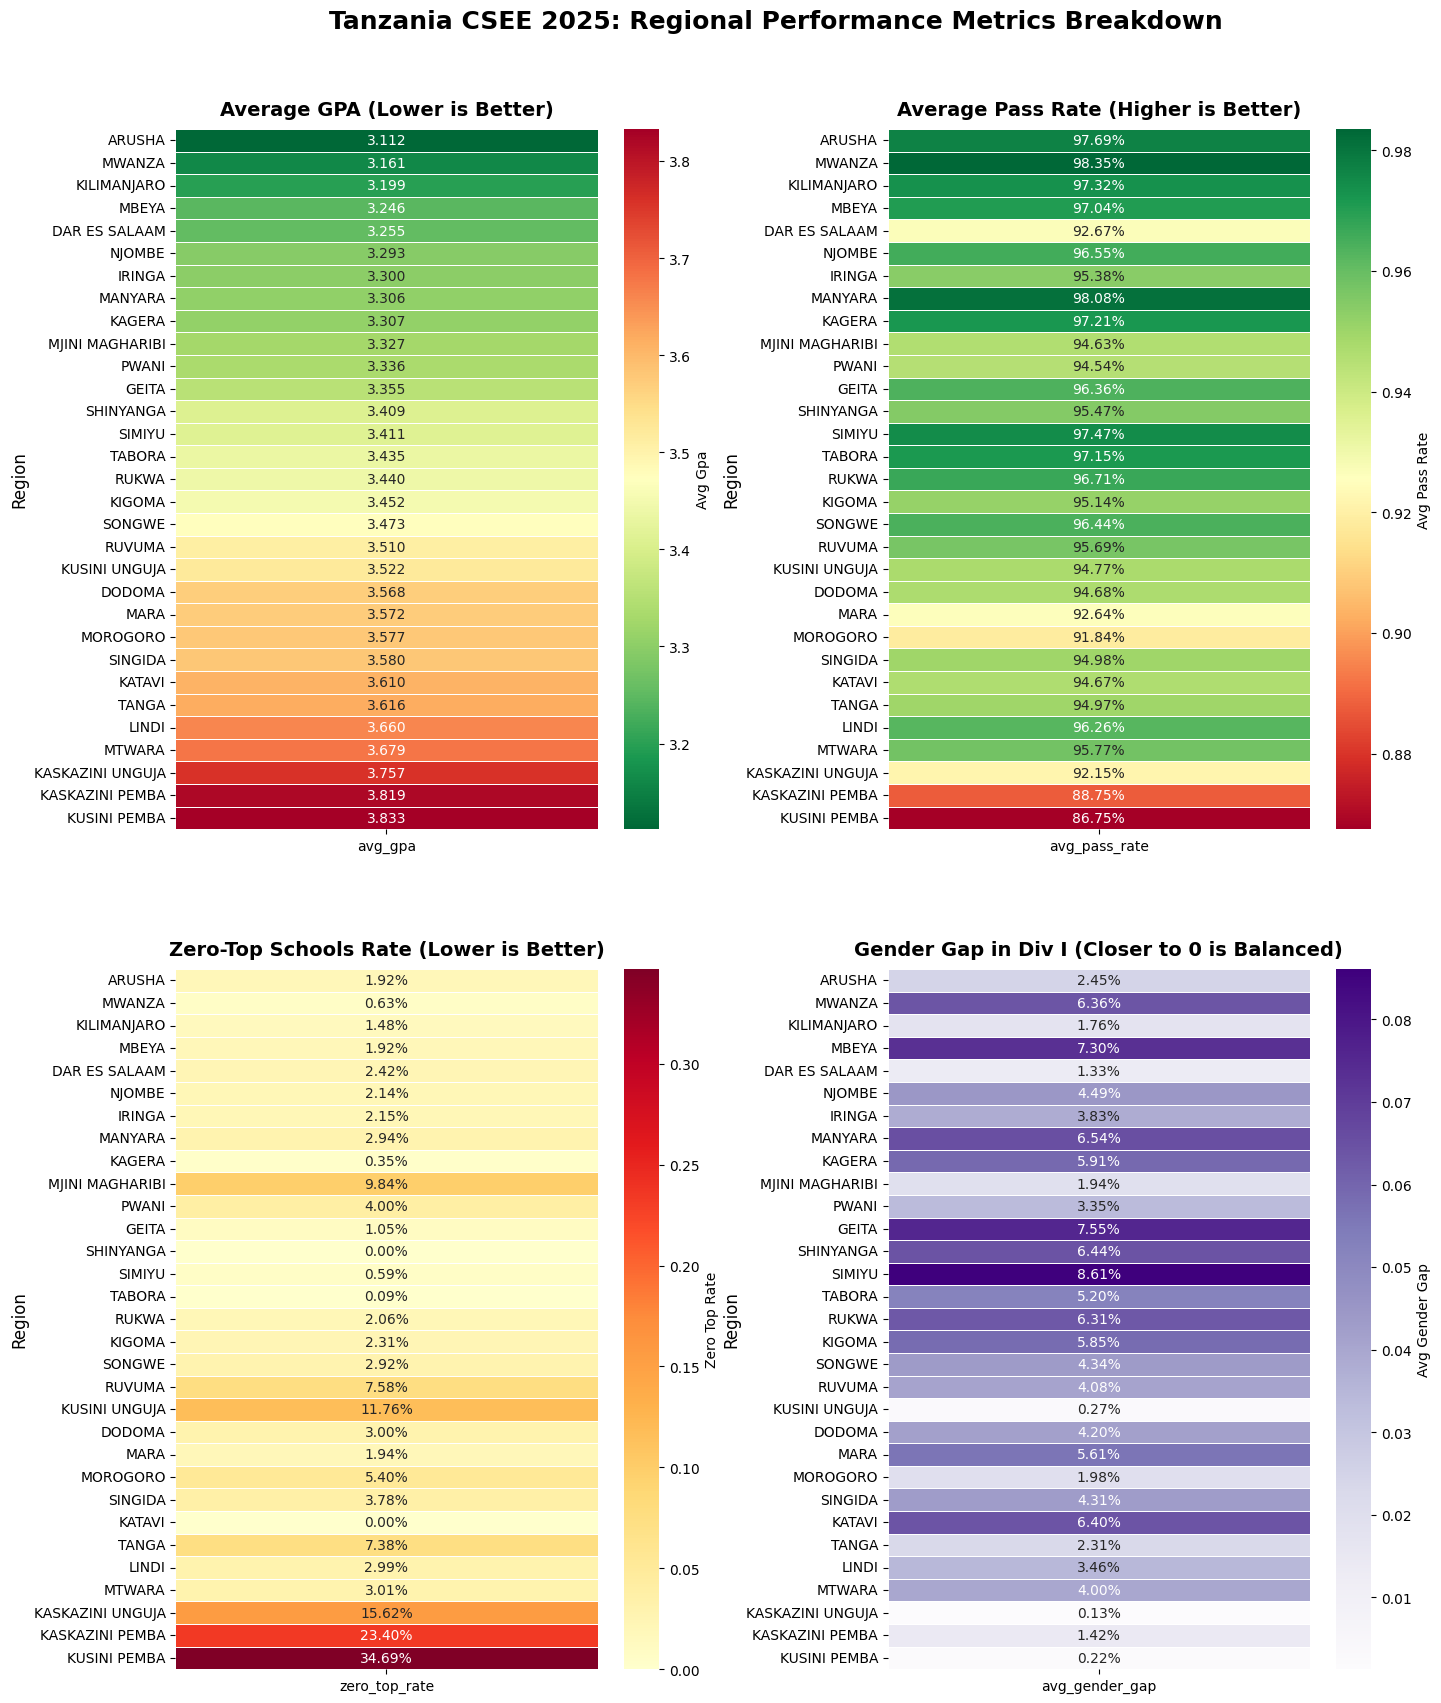

In [34]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

# 1. Load the data
data = {
    "region": [
        "ARUSHA",
        "MWANZA",
        "KILIMANJARO",
        "MBEYA",
        "DAR ES SALAAM",
        "NJOMBE",
        "IRINGA",
        "MANYARA",
        "KAGERA",
        "MJINI MAGHARIBI",
        "PWANI",
        "GEITA",
        "SHINYANGA",
        "SIMIYU",
        "TABORA",
        "RUKWA",
        "KIGOMA",
        "SONGWE",
        "RUVUMA",
        "KUSINI UNGUJA",
        "DODOMA",
        "MARA",
        "MOROGORO",
        "SINGIDA",
        "KATAVI",
        "TANGA",
        "LINDI",
        "MTWARA",
        "KASKAZINI UNGUJA",
        "KASKAZINI PEMBA",
        "KUSINI PEMBA",
    ],
    "avg_gpa": [
        3.1118,
        3.1607,
        3.1988,
        3.2460,
        3.2546,
        3.2932,
        3.2998,
        3.3061,
        3.3067,
        3.3274,
        3.3361,
        3.3554,
        3.4091,
        3.4114,
        3.4352,
        3.4403,
        3.4520,
        3.4729,
        3.5105,
        3.5224,
        3.5682,
        3.5717,
        3.5774,
        3.5797,
        3.6100,
        3.6164,
        3.6596,
        3.6795,
        3.7569,
        3.8191,
        3.8329,
    ],
    "avg_pass_rate": [
        0.9769,
        0.9835,
        0.9732,
        0.9704,
        0.9267,
        0.9655,
        0.9538,
        0.9808,
        0.9721,
        0.9463,
        0.9454,
        0.9636,
        0.9547,
        0.9747,
        0.9715,
        0.9671,
        0.9514,
        0.9644,
        0.9569,
        0.9477,
        0.9468,
        0.9264,
        0.9184,
        0.9498,
        0.9467,
        0.9497,
        0.9626,
        0.9577,
        0.9215,
        0.8875,
        0.8675,
    ],
    "zero_top_rate": [
        0.0192,
        0.0063,
        0.0148,
        0.0192,
        0.0242,
        0.0214,
        0.0215,
        0.0294,
        0.0035,
        0.0984,
        0.0400,
        0.0105,
        0.0000,
        0.0059,
        0.0009,
        0.0206,
        0.0231,
        0.0292,
        0.0758,
        0.1176,
        0.0300,
        0.0194,
        0.0540,
        0.0378,
        0.0000,
        0.0738,
        0.0299,
        0.0301,
        0.1562,
        0.2340,
        0.3469,
    ],
    "avg_gender_gap": [
        0.0245,
        0.0636,
        0.0176,
        0.0730,
        0.0133,
        0.0449,
        0.0383,
        0.0654,
        0.0591,
        0.0194,
        0.0335,
        0.0755,
        0.0644,
        0.0861,
        0.0520,
        0.0631,
        0.0585,
        0.0434,
        0.0408,
        0.0027,
        0.0420,
        0.0561,
        0.0198,
        0.0431,
        0.0640,
        0.0231,
        0.0346,
        0.0400,
        0.0013,
        0.0142,
        0.0022,
    ],
}

# I could've pulled from the data, but if one cell isn't working to well, this is easier to use.

df = pd.DataFrame(data).set_index("region")

# 2. Set up the 2x2 matplotlib subplot layout
fig, axes = plt.subplots(2, 2, figsize=(16, 20))
plt.subplots_adjust(wspace=0.35, hspace=0.2)

# Define metrics, custom titles, and color directions
# Note: For GPA, lower is better, so we use a reversed scale.
metrics = ["avg_gpa", "avg_pass_rate", "zero_top_rate", "avg_gender_gap"]
titles = [
    "Average GPA (Lower is Better)",
    "Average Pass Rate (Higher is Better)",
    "Zero-Top Schools Rate (Lower is Better)",
    "Gender Gap in Div I (Closer to 0 is Balanced)",
]
cmaps = ["RdYlGn_r", "RdYlGn", "YlOrRd", "Purples"]

# 3. Populate the 2x2 grid
for i, ax in enumerate(axes.flat):
    metric = metrics[i]

    # Reshape the single column to a 2D matrix structure for seaborn heatmap
    heatmap_data = df[[metric]]

    sns.heatmap(
        heatmap_data,
        cmap=cmaps[i],
        annot=True,
        fmt=".3f" if "gpa" in metric else ".2%",
        linewidths=0.5,
        ax=ax,
        cbar_kws={"label": metric.replace("_", " ").title()},
    )

    ax.set_title(titles[i], fontsize=14, fontweight="bold", pad=10)
    ax.set_ylabel("Region", fontsize=12)
    ax.set_xlabel("")

plt.suptitle(
    "Tanzania CSEE 2025: Regional Performance Metrics Breakdown",
    fontsize=18,
    fontweight="bold",
    y=0.94,
)
plt.show()